# BoVW Image Search Demo

This notebook shows how to build an index of BoVW histograms and perform image-to-image retrieval. You can choose between `cosine` similarity and `euclidean` distance, and optionally enable TF-IDF weighting for the histograms.

Make sure the dataset root is properly set (train/test split) and that you have trained or will train a model in this notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from bovw import BagOfVisualWordsClassifier, BoVWConfig

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# Configuration - adjust these for speed/quality
dataset_root = Path('caltech101_reduced')
feature_extractor = 'SIFT'   # SIFT, ORB, AKAZE, BRISK, KAZE, SURF(if available)
vocabulary_size = 64         # smaller for faster demo
use_tfidf = True             # set to False to disable TF-IDF weighting

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=vocabulary_size,
    max_descriptors_per_image=250,
    max_vocabulary_descriptors=10000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)
print('Supported extractors:', model.supported_extractors())

# Train the model (will read images under train/<class>/)
print('Training...')
model.fit(dataset_root / 'train')
print('Training finished.')

Supported extractors: ['SIFT', 'SURF', 'ORB', 'AKAZE', 'BRISK', 'KAZE']
Training...
Training finished.


In [8]:
# Build an index from the test set
test_images = sorted([p for p in (dataset_root / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}])
print(f'Found {len(test_images)} test images to index')

print('Indexing... (this may take a while)')
model.index_dataset(test_images, use_tfidf=use_tfidf)
print('Index built. Indexed features shape:', getattr(model, '_index_features').shape)

Found 46 test images to index
Indexing... (this may take a while)
Index built. Indexed features shape: (46, 64)


In [9]:
# Persist the retrieval index and load it back
index_path = Path('artifacts') / 'bovw_search_index.pkl'
saved_index = model.save_index(index_path)
loaded_model = model.load_index(saved_index)
print('Saved index to:', saved_index)
print('Loaded index entries:', len(loaded_model._index_paths))
print('TF-IDF enabled:', getattr(loaded_model, '_index_use_tfidf', False))

Saved index to: artifacts\bovw_search_index.pkl
Loaded index entries: 46
TF-IDF enabled: True


Query image: caltech101_reduced\test\accordion\image_0010.jpg


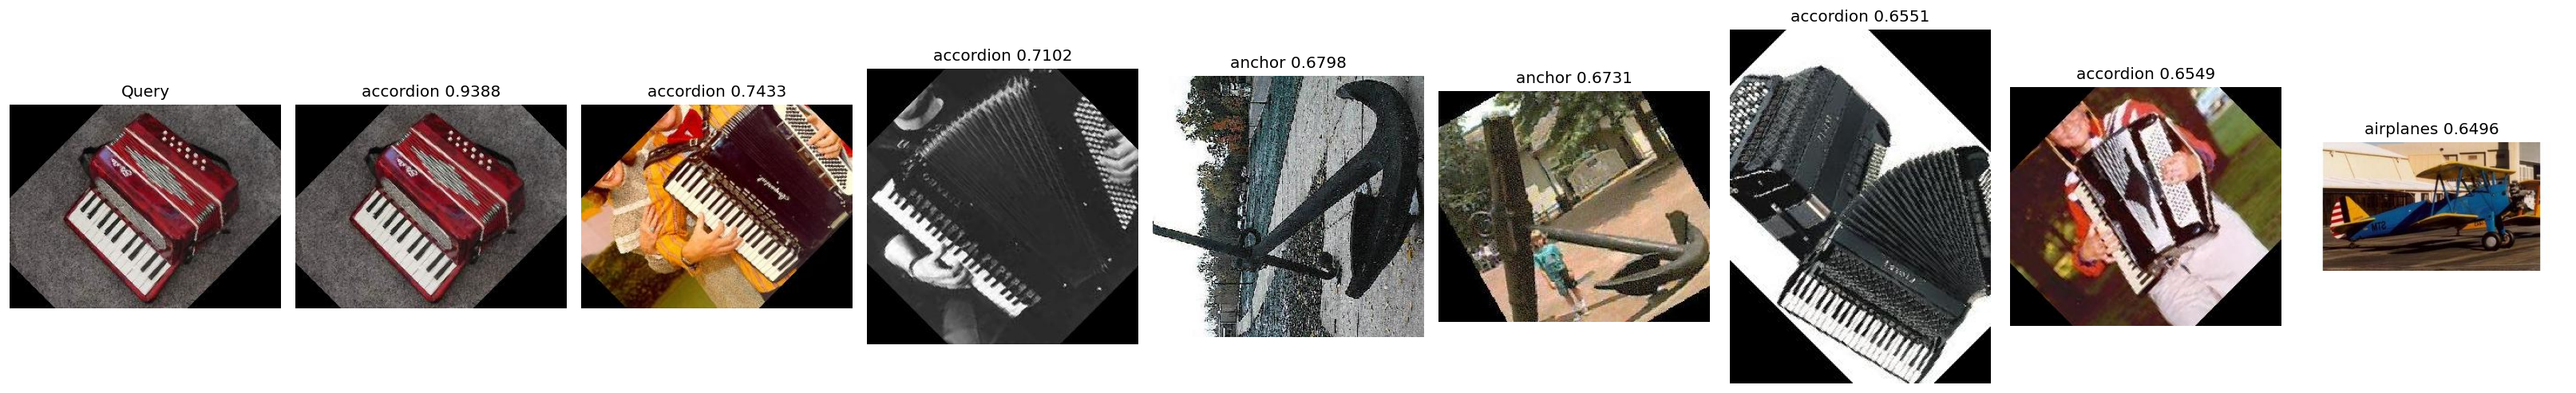

In [10]:
# Choose a query image (change index to try other queries)
query_idx = 0
query_path = test_images[query_idx]
print('Query image:', query_path)

# Run retrieval - try metric='cosine' or 'euclidean'
results = loaded_model.query(query_path, top_k=8, metric='cosine', use_tfidf=None)

# Display query and results
n = len(results) + 1
fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
# show query
qimg = Image.open(query_path).convert('RGB')
axes[0].imshow(qimg)
axes[0].set_title('Query')
axes[0].axis('off')

for i, (p, score) in enumerate(results, start=1):
    img = Image.open(p).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f'{p.parent.name} {score:.4f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Evaluate retrieval metrics across multiple queries
n_queries = min(100, len(test_images))
if n_queries < len(test_images):
    idxs = np.linspace(0, len(test_images)-1, n_queries, dtype=int)
    sampled_queries = [test_images[i] for i in idxs]
else:
    sampled_queries = list(test_images)
print(f'Evaluating {len(sampled_queries)} queries (top_k={8})...')
loaded_model._reset_rng()
results = loaded_model.evaluate_retrieval(sampled_queries, top_k=8, metric='cosine', use_tfidf=None)
print('Mean Precision@8: {:.4f}'.format(results['mean_precision_at_k']))
print('Mean Recall@8: {:.4f}'.format(results['mean_recall_at_k']))
print('Mean Average Precision (mAP): {:.4f}'.format(results['mean_average_precision']))
import numpy as _np
ap_vals = _np.array(results['per_query_ap'])
print('AP mean {:.4f}, median {:.4f}'.format(ap_vals.mean(), _np.median(ap_vals)))

Evaluating 46 queries (top_k=8)...
Mean Precision@8: 0.3207
Mean Recall@8: 0.3047
Mean Average Precision (mAP): 0.3817
AP mean 0.3817, median 0.3676
